In [2]:
import numpy as np
import matplotlib.pyplot as plt



r1: [2 1 3]
r2: [0.70710678 2.12132034 3.        ]


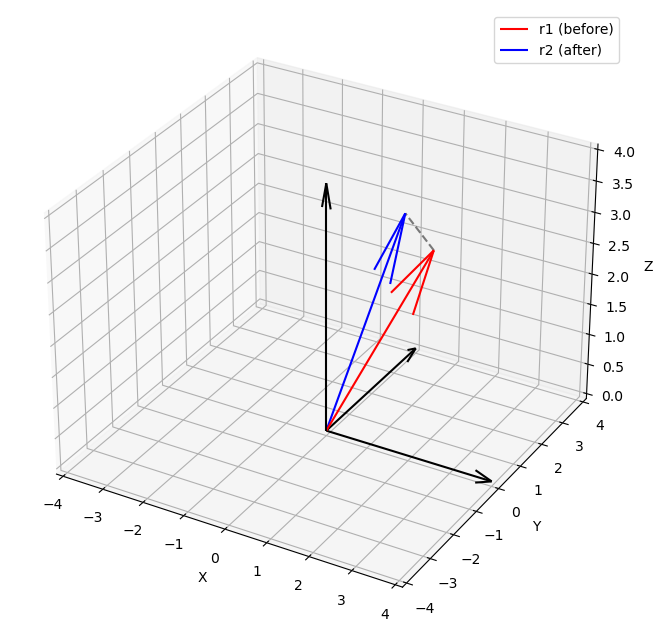

In [4]:


# ========== 1. ベクトルの定義 ==========
# 変換前のベクトル r1
r1 = np.array([2, 1, 3])  

# 回転角度（Z軸周りの回転）
alpha = np.pi / 4  # 45度

# Z軸回転行列 Rz(alpha)
Rz = np.array([
    [np.cos(alpha), -np.sin(alpha), 0],
    [np.sin(alpha),  np.cos(alpha), 0],
    [0,              0,             1]
])

# 変換後のベクトル r2
r2 = Rz @ r1

print("r1:", r1)
print("r2:", r2)

# ========== 2. 可視化 ==========
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")

# 軸範囲
lim = 4
ax.set_xlim([-lim, lim])
ax.set_ylim([-lim, lim])
ax.set_zlim([0, lim])

# 座標軸
ax.quiver(0,0,0, 4,0,0, color="k", arrow_length_ratio=0.1)
ax.quiver(0,0,0, 0,4,0, color="k", arrow_length_ratio=0.1)
ax.quiver(0,0,0, 0,0,4, color="k", arrow_length_ratio=0.1)

# ベクトル r1（赤）
ax.quiver(0,0,0, r1[0], r1[1], r1[2], color="red", label="r1 (before)")

# ベクトル r2（青）
ax.quiver(0,0,0, r2[0], r2[1], r2[2], color="blue", label="r2 (after)")

# 補助線（r1とr2を繋ぐ）
ax.plot([r1[0], r2[0]], [r1[1], r2[1]], [r1[2], r2[2]], "k--", alpha=0.5)

# 軸ラベル
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()


元のベクトル z: [2 2 3]
基底ベクトル u: [0.70710678 0.70710678 0.        ]
射影ベクトル z_proj: [2. 2. 0.]


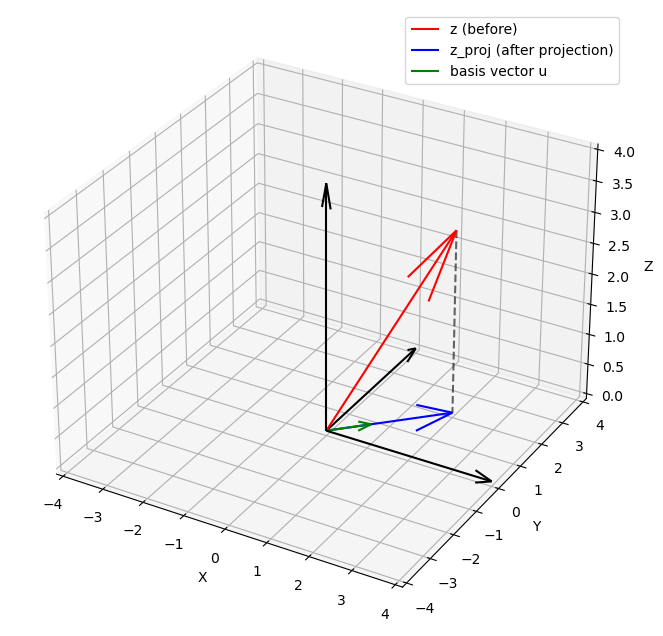

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 1. ベクトル定義 ==========
z = np.array([2, 2, 3])   # 射影するベクトル
u = np.array([1, 1, 0])   # 固有ベクトルの一例
u = u / np.linalg.norm(u) # 正規化（単位ベクトルに）

# ========== 2. 射影計算 ==========
z_proj = (u @ z) * u

print("元のベクトル z:", z)
print("基底ベクトル u:", u)
print("射影ベクトル z_proj:", z_proj)

# ========== 3. 可視化 ==========
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")

# 軸範囲
lim = 4
ax.set_xlim([-lim, lim])
ax.set_ylim([-lim, lim])
ax.set_zlim([0, lim])

# 座標軸
ax.quiver(0,0,0, 4,0,0, color="k", arrow_length_ratio=0.1)
ax.quiver(0,0,0, 0,4,0, color="k", arrow_length_ratio=0.1)
ax.quiver(0,0,0, 0,0,4, color="k", arrow_length_ratio=0.1)

# 元のベクトル z（赤）
ax.quiver(0,0,0, z[0], z[1], z[2], color="red", label="z (before)")

# 射影後のベクトル z_proj（青）
ax.quiver(0,0,0, z_proj[0], z_proj[1], z_proj[2], color="blue", label="z_proj (after projection)")

# 基底ベクトル u（緑）
ax.quiver(0,0,0, u[0], u[1], u[2], color="green", label="basis vector u")

# z から z_proj への補助線
ax.plot([z[0], z_proj[0]], [z[1], z_proj[1]], [z[2], z_proj[2]], "k--", alpha=0.6)

# 軸ラベル
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()


元のベクトル z: [2 2 3]
射影ベクトル z_proj: [1.33333333 2.66666667 0.33333333]


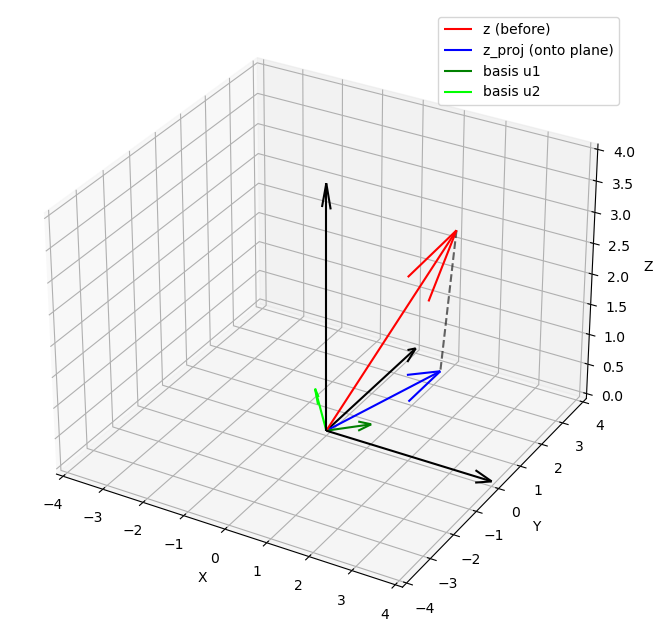

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 1. 元のベクトル ==========
z = np.array([2, 2, 3])

# ========== 2. 基底ベクトル（例: ランダムに2つ生成して直交化） ==========
# 固有ベクトルを想定
u1 = np.array([4, 4, 0])
u2 = np.array([-4, 4, 2.0])

# 正規直交化（Gram-Schmidt）
u1 = u1 / np.linalg.norm(u1)
u2 = u2 - (u1 @ u2) * u1
u2 = u2 / np.linalg.norm(u2)

U = np.column_stack([u1, u2])  # (3,2)

# ========== 3. 平面への射影 ==========
z_proj = U @ (U.T @ z)

print("元のベクトル z:", z)
print("射影ベクトル z_proj:", z_proj)

# ========== 4. 可視化 ==========
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")

lim = 4
ax.set_xlim([-lim, lim])
ax.set_ylim([-lim, lim])
ax.set_zlim([0, lim])

# 座標軸
ax.quiver(0,0,0, 4,0,0, color="k", arrow_length_ratio=0.1)
ax.quiver(0,0,0, 0,4,0, color="k", arrow_length_ratio=0.1)
ax.quiver(0,0,0, 0,0,4, color="k", arrow_length_ratio=0.1)

# 元のベクトル z（赤）
ax.quiver(0,0,0, z[0], z[1], z[2], color="red", label="z (before)")

# 射影後のベクトル z_proj（青）
ax.quiver(0,0,0, z_proj[0], z_proj[1], z_proj[2], color="blue", label="z_proj (onto plane)")

# 基底ベクトル（緑）
ax.quiver(0,0,0, u1[0], u1[1], u1[2], color="green", label="basis u1")
ax.quiver(0,0,0, u2[0], u2[1], u2[2], color="lime", label="basis u2")

# z から z_proj への補助線
ax.plot([z[0], z_proj[0]], [z[1], z_proj[1]], [z[2], z_proj[2]], "k--", alpha=0.6)

# 軸ラベル
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()


元の z: [2 2 3]
重要成分 z_imp: [1.33333333 2.66666667 0.33333333]
非重要成分 z_non: [ 0.66666667 -0.66666667  2.66666667]
復元 z: [2. 2. 3.]


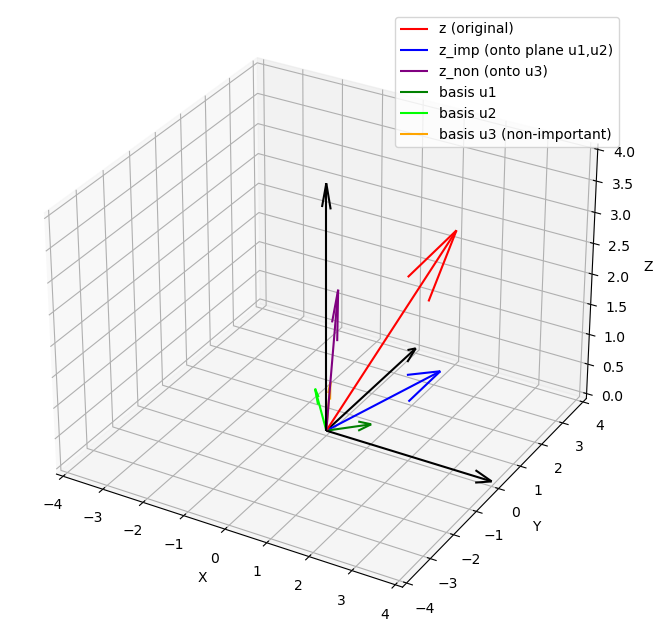

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 1. 元のベクトル ==========
z = np.array([2, 2, 3])

# ========== 2. 基底ベクトル（例: 適当に3本作って直交化） ==========
u1 = np.array([1, 1, 0])
u2 = np.array([-1, 1, 0.5])
u3 = np.cross(u1, u2)  # 直交補を作る

# 正規直交化
u1 = u1 / np.linalg.norm(u1)
u2 = u2 - (u1 @ u2) * u1
u2 = u2 / np.linalg.norm(u2)
u3 = u3 / np.linalg.norm(u3)

# 行列 U
U = np.column_stack([u1, u2, u3])

# ========== 3. 射影計算 ==========
# 重要平面への射影
z_imp = (u1 @ z) * u1 + (u2 @ z) * u2
# 非重要軸への射影
z_non = (u3 @ z) * u3

print("元の z:", z)
print("重要成分 z_imp:", z_imp)
print("非重要成分 z_non:", z_non)
print("復元 z:", z_imp + z_non)

# ========== 4. 可視化 ==========
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")

lim = 4
ax.set_xlim([-lim, lim])
ax.set_ylim([-lim, lim])
ax.set_zlim([0, lim])

# 座標軸
ax.quiver(0,0,0, 4,0,0, color="k", arrow_length_ratio=0.1)
ax.quiver(0,0,0, 0,4,0, color="k", arrow_length_ratio=0.1)
ax.quiver(0,0,0, 0,0,4, color="k", arrow_length_ratio=0.1)

# 元のベクトル（赤）
ax.quiver(0,0,0, z[0], z[1], z[2], color="red", label="z (original)")

# 重要成分（青）
ax.quiver(0,0,0, z_imp[0], z_imp[1], z_imp[2], color="blue", label="z_imp (onto plane u1,u2)")

# 非重要成分（紫）
ax.quiver(0,0,0, z_non[0], z_non[1], z_non[2], color="purple", label="z_non (onto u3)")

# 基底ベクトル表示（緑）
ax.quiver(0,0,0, u1[0], u1[1], u1[2], color="green", label="basis u1")
ax.quiver(0,0,0, u2[0], u2[1], u2[2], color="lime", label="basis u2")
ax.quiver(0,0,0, u3[0], u3[1], u3[2], color="orange", label="basis u3 (non-important)")

# z と z_imp+z_non の関係を点線で補助
ax.plot([z[0], (z_imp+z_non)[0]], [z[1], (z_imp+z_non)[1]], [z[2], (z_imp+z_non)[2]], "k--", alpha=0.6)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()


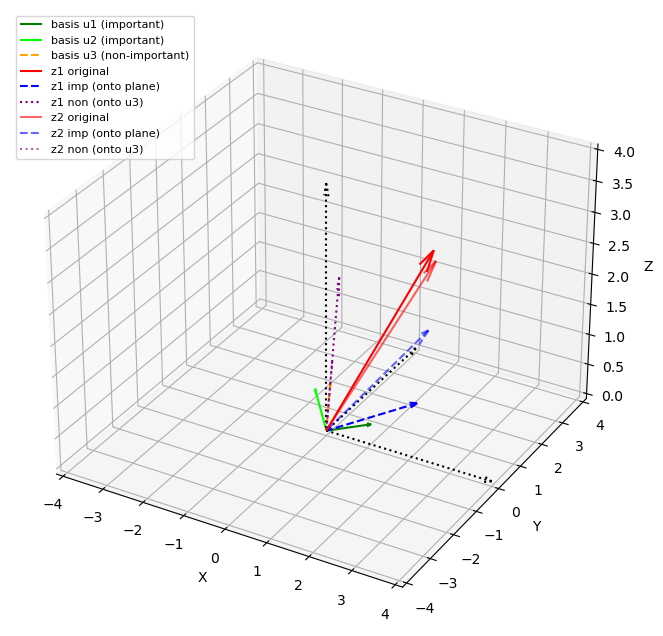

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 1. 例としてベクトルを2本用意 ==========
z1 = np.array([2, 1, 3])
z2 = np.array([1, 3, 2])

# ========== 2. 基底ベクトルを定義（正規直交化） ==========
u1 = np.array([1, 1, 0])
u2 = np.array([-1, 1, 0.5])
u3 = np.cross(u1, u2)  # 直交補

# 正規直交化
u1 = u1 / np.linalg.norm(u1)
u2 = u2 - (u1 @ u2) * u1
u2 = u2 / np.linalg.norm(u2)
u3 = u3 / np.linalg.norm(u3)

# ========== 3. 射影計算関数 ==========
def project(z, u1, u2, u3):
    z_imp = (u1 @ z) * u1 + (u2 @ z) * u2
    z_non = (u3 @ z) * u3
    return z_imp, z_non

z1_imp, z1_non = project(z1, u1, u2, u3)
z2_imp, z2_non = project(z2, u1, u2, u3)

# ========== 4. 可視化 ==========
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

lim = 4
ax.set_xlim([-lim, lim])
ax.set_ylim([-lim, lim])
ax.set_zlim([0, lim])

# ===== 座標軸 =====
ax.quiver(0,0,0, 4,0,0, color="k", arrow_length_ratio=0.05, linestyle="dotted")
ax.quiver(0,0,0, 0,4,0, color="k", arrow_length_ratio=0.05, linestyle="dotted")
ax.quiver(0,0,0, 0,0,4, color="k", arrow_length_ratio=0.05, linestyle="dotted")

# ===== 基底ベクトル =====
ax.quiver(0,0,0, u1[0], u1[1], u1[2], color="green", arrow_length_ratio=0.1, linestyle="-", label="basis u1 (important)")
ax.quiver(0,0,0, u2[0], u2[1], u2[2], color="lime", arrow_length_ratio=0.1, linestyle="-", label="basis u2 (important)")
ax.quiver(0,0,0, u3[0], u3[1], u3[2], color="orange", arrow_length_ratio=0.1, linestyle="--", label="basis u3 (non-important)")

# ===== ベクトル1 =====
ax.quiver(0,0,0, z1[0], z1[1], z1[2], color="red", arrow_length_ratio=0.1, linestyle="-", label="z1 original")
ax.quiver(0,0,0, z1_imp[0], z1_imp[1], z1_imp[2], color="blue", arrow_length_ratio=0.1, linestyle="--", label="z1 imp (onto plane)")
ax.quiver(0,0,0, z1_non[0], z1_non[1], z1_non[2], color="purple", arrow_length_ratio=0.1, linestyle=":", label="z1 non (onto u3)")

# ===== ベクトル2 =====
ax.quiver(0,0,0, z2[0], z2[1], z2[2], color="red", arrow_length_ratio=0.1, linestyle="-", alpha=0.6, label="z2 original")
ax.quiver(0,0,0, z2_imp[0], z2_imp[1], z2_imp[2], color="blue", arrow_length_ratio=0.1, linestyle="--", alpha=0.6, label="z2 imp (onto plane)")
ax.quiver(0,0,0, z2_non[0], z2_non[1], z2_non[2], color="purple", arrow_length_ratio=0.1, linestyle=":", alpha=0.6, label="z2 non (onto u3)")

# ===== 軸ラベル =====
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend(loc="upper left", fontsize=8)

plt.show()


In [21]:
u1, u2, u3

(array([0.70710678, 0.70710678, 0.        ]),
 array([-0.66666667,  0.66666667,  0.33333333]),
 array([ 0.23570226, -0.23570226,  0.94280904]))

In [15]:
z1, z1_imp+z1_non

(array([2, 1, 3]), array([2., 1., 3.]))

In [14]:

def check_orthogonality(u1, u2, u3, tol=1e-8):
    U = np.column_stack([u1, u2, u3])   # (3,3)
    
    # 内積行列（Gram行列）
    G = U.T @ U
    
    print("Gram行列 U^T U:\n", G)
    
    # 直交性の確認
    if np.allclose(G, np.eye(3), atol=tol):
        print("u1, u2, u3 は直交かつ正規化されています（直交正規基底）✅")
    else:
        print("完全には直交していません。再直交化が必要です。⚠️")


check_orthogonality(u1, u2, u3)

Gram行列 U^T U:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
u1, u2, u3 は直交かつ正規化されています（直交正規基底）✅


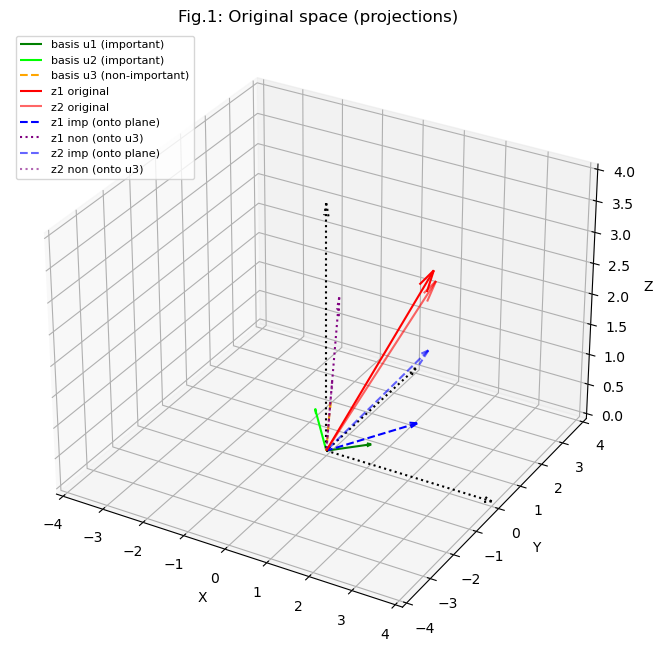

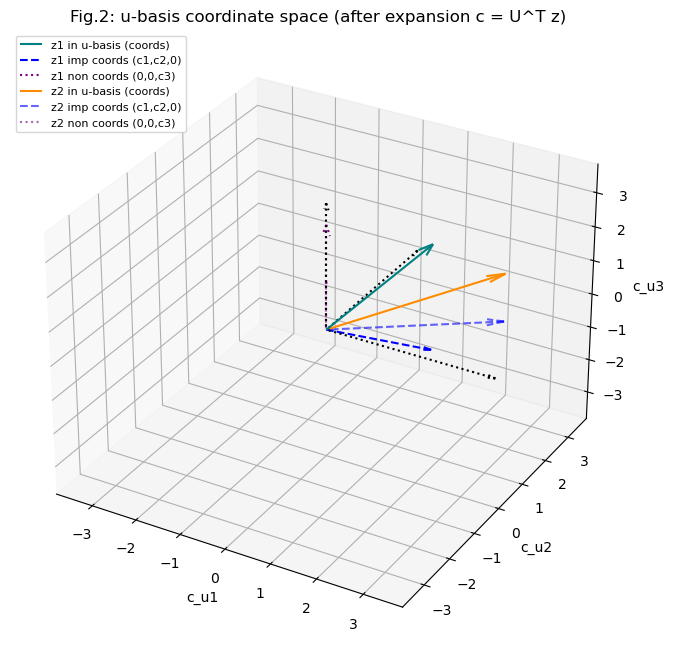

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 1. 例としてベクトルを2本用意 ==========
z1 = np.array([2, 1, 3])
z2 = np.array([1, 3, 2])

# ========== 2. 基底ベクトルを定義（正規直交化） ==========
u1 = np.array([1, 1, 0])
u2 = np.array([-1, 1, 0.5])
u3 = np.cross(u1, u2)  # 直交補

# 正規直交化（Gram-Schmidt）
u1 = u1 / np.linalg.norm(u1)
u2 = u2 - (u1 @ u2) * u1
u2 = u2 / np.linalg.norm(u2)
u3 = u3 / np.linalg.norm(u3)

U = np.column_stack([u1, u2, u3])  # (3,3)

# ========== 3. 射影計算関数（元の空間でのベクトル分解） ==========
def project_in_original_space(z, u1, u2, u3):
    z_imp = (u1 @ z) * u1 + (u2 @ z) * u2     # 重要平面への射影（元の空間）
    z_non = (u3 @ z) * u3                     # 非重要軸への射影（元の空間）
    return z_imp, z_non

z1_imp, z1_non = project_in_original_space(z1, u1, u2, u3)
z2_imp, z2_non = project_in_original_space(z2, u1, u2, u3)

# ========== 4. 座標変換（u-座標＝展開した直後の“係数”） ==========
# ここが今回の追加：標準基底ではなく u1,u2,u3 基底での「座標」c = U^T z を直接可視化する
c1 = U.T @ z1   # (c1_u1, c1_u2, c1_u3)
c2 = U.T @ z2   # (c2_u1, c2_u2, c2_u3)

# 係数空間での重要/非重要成分（= 座標の分解）
c1_imp = np.array([c1[0], c1[1], 0.0])
c1_non = np.array([0.0, 0.0, c1[2]])
c2_imp = np.array([c2[0], c2[1], 0.0])
c2_non = np.array([0.0, 0.0, c2[2]])

# ========== 5-A. 図1：元の空間での射影可視化 ==========
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

lim = 4
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([0, lim])

# 座標軸（点線）
ax.quiver(0,0,0, 4,0,0, color="k", arrow_length_ratio=0.05, linestyle="dotted")
ax.quiver(0,0,0, 0,4,0, color="k", arrow_length_ratio=0.05, linestyle="dotted")
ax.quiver(0,0,0, 0,0,4, color="k", arrow_length_ratio=0.05, linestyle="dotted")

# 基底ベクトル（種類を変える）
ax.quiver(0,0,0, u1[0], u1[1], u1[2], color="green",  arrow_length_ratio=0.1, linestyle="-",  label="basis u1 (important)")
ax.quiver(0,0,0, u2[0], u2[1], u2[2], color="lime",   arrow_length_ratio=0.1, linestyle="-",  label="basis u2 (important)")
ax.quiver(0,0,0, u3[0], u3[1], u3[2], color="orange", arrow_length_ratio=0.1, linestyle="--", label="basis u3 (non-important)")

# z1, z2（元の空間）
ax.quiver(0,0,0, z1[0], z1[1], z1[2], color="red",   arrow_length_ratio=0.1, linestyle="-",  label="z1 original")
ax.quiver(0,0,0, z2[0], z2[1], z2[2], color="red",   arrow_length_ratio=0.1, linestyle="-",  alpha=0.6, label="z2 original")

# 射影（元の空間）
ax.quiver(0,0,0, z1_imp[0], z1_imp[1], z1_imp[2], color="blue",   arrow_length_ratio=0.1, linestyle="--", label="z1 imp (onto plane)")
ax.quiver(0,0,0, z1_non[0], z1_non[1], z1_non[2], color="purple", arrow_length_ratio=0.1, linestyle=":",  label="z1 non (onto u3)")
ax.quiver(0,0,0, z2_imp[0], z2_imp[1], z2_imp[2], color="blue",   arrow_length_ratio=0.1, linestyle="--", alpha=0.6, label="z2 imp (onto plane)")
ax.quiver(0,0,0, z2_non[0], z2_non[1], z2_non[2], color="purple", arrow_length_ratio=0.1, linestyle=":",  alpha=0.6, label="z2 non (onto u3)")

ax.set_title("Fig.1: Original space (projections)")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.legend(loc="upper left", fontsize=8)
plt.show()

# ========== 5-B. 図2：u-座標空間で“展開直後の座標”を可視化 ==========
# ここでは座標軸そのものが「u1,u2,u3 係数」であり、c = U^T z を矢印で描く
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection="3d")

# 係数空間の表示範囲を自動で設定
all_coords = np.vstack([c1, c2])
m = np.max(np.abs(all_coords)) * 1.2
m = max(m, 1.0)
ax2.set_xlim([-m, m]); ax2.set_ylim([-m, m]); ax2.set_zlim([-m, m])

# 係数空間の軸（点線）
ax2.quiver(0,0,0, m,0,0, color="k", arrow_length_ratio=0.05, linestyle="dotted")
ax2.quiver(0,0,0, 0,m,0, color="k", arrow_length_ratio=0.05, linestyle="dotted")
ax2.quiver(0,0,0, 0,0,m, color="k", arrow_length_ratio=0.05, linestyle="dotted")

# z1 の u-座標（展開直後）
ax2.quiver(0,0,0, c1[0], c1[1], c1[2], arrow_length_ratio=0.1, linestyle="-",  color="teal",   label="z1 in u-basis (coords)")
# その分解（重要/非重要）… 係数空間なので c_imp=(c1,c2,0), c_non=(0,0,c3)
ax2.quiver(0,0,0, c1_imp[0], c1_imp[1], c1_imp[2], arrow_length_ratio=0.1, linestyle="--", color="blue",   label="z1 imp coords (c1,c2,0)")
ax2.quiver(0,0,0, c1_non[0], c1_non[1], c1_non[2], arrow_length_ratio=0.1, linestyle=":",  color="purple", label="z1 non coords (0,0,c3)")

# z2 の u-座標（展開直後）
ax2.quiver(0,0,0, c2[0], c2[1], c2[2], arrow_length_ratio=0.1, linestyle="-",  color="darkorange",  label="z2 in u-basis (coords)")
ax2.quiver(0,0,0, c2_imp[0], c2_imp[1], c2_imp[2], arrow_length_ratio=0.1, linestyle="--", color="blue",        alpha=0.6, label="z2 imp coords (c1,c2,0)")
ax2.quiver(0,0,0, c2_non[0], c2_non[1], c2_non[2], arrow_length_ratio=0.1, linestyle=":",  color="purple",      alpha=0.6, label="z2 non coords (0,0,c3)")

ax2.set_title("Fig.2: u-basis coordinate space (after expansion c = U^T z)")
ax2.set_xlabel("c_u1"); ax2.set_ylabel("c_u2"); ax2.set_zlabel("c_u3")
ax2.legend(loc="upper left", fontsize=8)
plt.show()


In [18]:
z1_imp, z1_non

(2.454653676892976, 3.0641293851417064)